In [ ]:
import sys
from pathlib import Path
import os
from mmengine import Config
import time
from IPython.display import display, clear_output
import matplotlib.pyplot as plt


parent_folder = Path(os.getcwd()).parent  # parent of current folder
sys.path.insert(0, str(parent_folder))


from PhaseDataset import PhaseDataset

In [18]:
device = 'cuda' # set to "cpu" if Cuda is not available
    
paramfile = 'dataset_params.py'  # file of experimental parameters


# Config extraction
AtmosParams = Config.fromfile(paramfile)['AtmosParams']
WFSParams = Config.fromfile(paramfile)['WFSParams']
LoopParams = Config.fromfile(paramfile)['LoopParams']

# Dataset creation
dataset = PhaseDataset(WFSParams, AtmosParams, LoopParams, device)

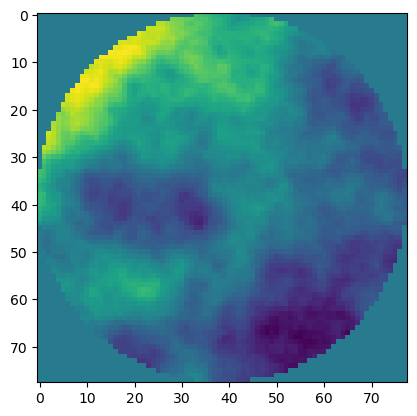

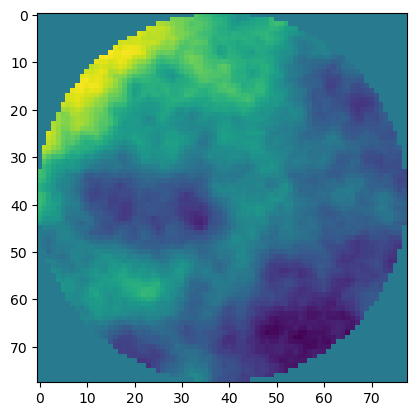

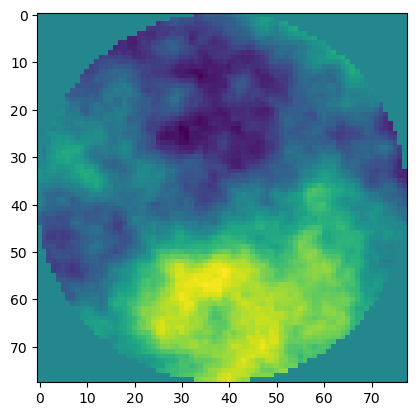

In [27]:
## You can get the phase, decomposition and many other parameters by calling the GetMovingWavefront function
phaseGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset.GetMovingWavefront(generateClosedLoop = True)
plt.figure()
plt.imshow(phaseGT[0].cpu())
## Each subsequent call from that function will NOT generate a new wavefront, but it will displace it given the wind speeds of each layer.
phaseGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset.GetMovingWavefront()
plt.figure()
plt.imshow(phaseGT[0].cpu())

## If you want to get new wavefronts, you need to reset the dataset and call again the GetMovingWavefront function
dataset.ResetMovingWavefront()
phaseGT,zernike,photons,RON,r0,wind_speed,fractional_r0 = dataset.GetMovingWavefront()
plt.figure()
plt.imshow(phaseGT[0].cpu())

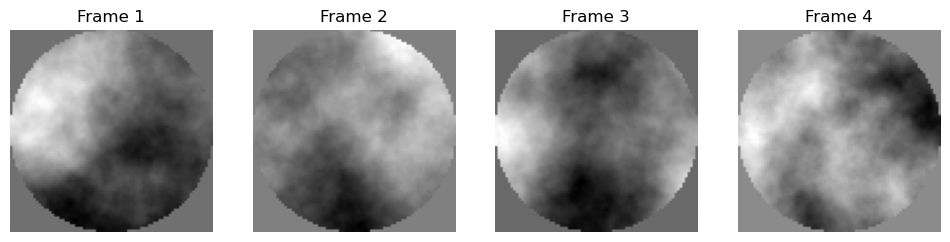

In [28]:
## You can see how the wavefronts move given the wind

n_iter = 100

for i in range(n_iter):
    phaseGT,zernike,_,_,_,_,_ = dataset.GetMovingWavefront()
    # Clear previous output (without flickering)
    clear_output(wait=True)

    frames = phaseGT[:4]

    num_frames = frames.shape[0]

    # Create subplots: 1 row, num_frames columns
    fig, axes = plt.subplots(1, num_frames, figsize=(3*num_frames, 3))
    
    # Ensure axes is iterable if num_frames = 1
    if num_frames == 1:
        axes = [axes]

    for j, frame in enumerate(frames.cpu()):
        axes[j].imshow(frame, cmap='gray')
        axes[j].set_title(f"Frame {j+1}")
        axes[j].axis('off')


    # Display the frame
    display(plt.gcf())
    
    # Pause so you can see the frame (adjust as needed)
    time.sleep(0.01)

    # Close the figure to prevent memory buildup
    plt.close()